In [4]:
# pip install huggingface_hub pandas
from huggingface_hub import hf_hub_download
import pandas as pd

path = hf_hub_download(
    repo_id="McAuley-Lab/Amazon-Reviews-2023",
    filename="raw/meta_categories/meta_All_Beauty.jsonl",
    repo_type="dataset",
)

df = pd.read_json(path, lines=True)   # one product per line

print("Number of products:", len(df))
print("\nColumns:", list(df.columns))
print(df.iloc[7])                      # one full raw product

/Users/tarkshya/Work/LLM Engineering/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of products: 112590

Columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']
main_category                                             All Beauty
title              50 Pieces False Eyelash Packaging Box Empty Ey...
average_rating                                                   3.8
rating_number                                                     32
features                                                          []
description                                                       []
price                                                            NaN
images             [{'thumb': 'https://m.media-amazon.com/images/...
videos                                                            []
store                                                         Maitys
categories                                                        []
details           

In [5]:
for i, row in df.sample(5, random_state=42).iterrows():
    print("=" * 80)
    print("TITLE:", row["title"])
    print("PRICE:", row["price"])
    print("FEATURES:", row["features"])
    print("DESCRIPTION:", row["description"])
    print("DETAILS:", row["details"])

TITLE: Pink Lace Front Wigs Long Straight Hair Wig Glueless Heat Resistant Fiber Hair Pink Synthetic Lace Front Wigs for Fashion Women (PINK)
PRICE: nan
FEATURES: []
DESCRIPTION: []
DETAILS: {'Material': 'Synthetic', 'Hair Type': 'Straight', 'Style': 'Modern', 'Special Feature': 'Glueless', 'Brand': 'DLME', 'Package Dimensions': '12.7 x 5.7 x 2.5 inches; 13.62 Ounces', 'UPC': '712179940338'}
TITLE: Anti-aging sunscreen SPF 50+ Duolys, 50 ml, Acm
PRICE: 25.0
FEATURES: []
DESCRIPTION: []
DETAILS: {'Sun Protection': '50 SPF', 'Item Weight': '0.08 Kilograms', 'Unit Count': '1.00 Count', 'Skin Type': 'Sensitive', 'Item Dimensions LxWxH': '1.46 x 1.46 x 6.1 inches', 'Product Dimensions': '1.46 x 1.46 x 6.1 inches; 2.82 Ounces', 'Item model number': 'ACM-PF/DUA-003'}
TITLE: J-Beauty Jade Roller for Face – Jade Roller Massager Anti-Aging – Facial Roller Skin Care SPA and Treatment – Best Wrinkle Prevention Action – Natural Dark Spots Remedy – Gift Box Included
PRICE: nan
FEATURES: ['UPGRADED B

In [6]:
total = len(df)
missing = df["price"].isna().sum()

print(f"Total products:     {total}")
print(f"Missing price:       {missing} {missing / total * 100:.1f}%)")

priced = df[df["price"].notna()].copy()
print(f"Products with a price: {len(priced)}")

Total products:     112590
Missing price:       94886 84.3%)
Products with a price: 17704


In [7]:
def show_product(row):
    print("=" * 80)
    print("TITLE:", row["title"])
    print("PRICE:", row["price"])
    print("NUMBER OF FEATURES:", len(row["features"]))
    print("DESCRIPTION LENGTH (chars):", len(" ".join(row["description"])))

for i, row in priced.sample(5, random_state=42).iterrows():
    show_product(row)

TITLE: C.O. Bigelow 2 pack Mentha Lip Tint Pink Mint Formula No 1644 and Mentha Lip Tint Violet Mint Formula No 1646 NEW PACKAGING
PRICE: 39.99
NUMBER OF FEATURES: 0
DESCRIPTION LENGTH (chars): 0
TITLE: Young Nails False Nail, Diamond Dust
PRICE: 9.79
NUMBER OF FEATURES: 0
DESCRIPTION LENGTH (chars): 0
TITLE: Body Fantasies Daydream Darling by Parfums De Coeur Body Spray 8 oz Women
PRICE: 8.85
NUMBER OF FEATURES: 0
DESCRIPTION LENGTH (chars): 5
TITLE: Magical shampoo"Scalp brush" SCALP BRUSH WORLD MODEL/SHORT (made in Japan)
PRICE: 48.99
NUMBER OF FEATURES: 0
DESCRIPTION LENGTH (chars): 415
TITLE: Activated Bamboo Charcoal Clear Skin Mask Peel 20% Papaya Pineapple Enzyme+Glycolic w/Argireline, Hyluronic Acid, Vit. C, E, CoQ10. Natural/Organic 2 OZ
PRICE: 34.95
NUMBER OF FEATURES: 0
DESCRIPTION LENGTH (chars): 0


count    17704.00000
mean        27.25573
std         50.47202
min          0.01000
25%          9.99000
50%         16.99000
75%         29.90000
max       2548.98000
Name: price, dtype: float64
$  2548.98   Standing Power Body Lift (Lumex Easy Lift STS -LF2020) w/(FREE Sit to Stand Padd
$  2199.00   Crystal Microdermabrasion w/German Motor, 2 year warranty
$  2143.46   Dr.Arrivo ZeusⅡ (Red)
$  1485.00   SupaScoota Hemi - Orange Standard Model Lightweight Travel Mobility Take Apart S
$  1378.32   EasySwing Cow Brush - Large - Cow Comfort Cattle Brush - Cow Scratcher works for
$  1185.72   Top Form 12" Renau Exclusive Human Hair Hairpiece by Jon Renau
$  1069.00   Golden Technologies Cambridge Medium/Large Lift Chair PR-401-MLA with Copper Fab
$  1000.00   TA-65 For Skin Telomerase Complex 4floz TA Sciences
$   996.00   Cambridge Small/Medium Lift Chair by Golden Technologies PR-401-SME with Pearl F
$   699.99   VENOFYE BIO SYRINGE


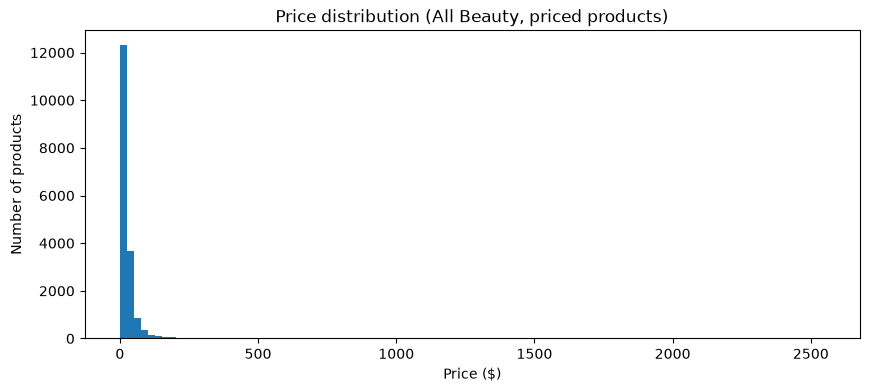

In [8]:
import matplotlib.pyplot as plt

# Make sure every price is a real number; anything that isn't becomes NaN, then drop those
priced["price"] = pd.to_numeric(priced["price"], errors="coerce")
priced = priced[priced["price"].notna()]

# Summary numbers
print(priced["price"].describe())

# The 10 most expensive products: are they real or errors?
top = priced.sort_values("price", ascending=False).head(10)
for i, row in top.iterrows():
    print(f"${row['price']:>9.2f}   {row['title'][:80]}")

# Histogram of prices
plt.figure(figsize=(10, 4))
plt.hist(priced["price"], bins=100)
plt.xlabel("Price ($)")
plt.ylabel("Number of products")
plt.title("Price distribution (All Beauty, priced products)")
plt.show()

Step 3b: Choosing the cutoffs

Concept: we can use percentiles. The 99th percentile is the price that 99% of products are below. If we cut at, say, the 1st and 99th percentiles, we keep the middle 98% of products and remove only the extremes at each end.

In [9]:
# Prices at several percentiles
for p in [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]:
    print(f"{int(p * 100):>3}th percentile: ${priced['price'].quantile(p):.2f}")

# Try a candidate range and see how many products it keeps
low, high = 5, 1400       # <- change these to test your own choice
kept = priced[(priced["price"] >= low) & (priced["price"] <= high)]
print(f"\nRange ${low}–${high} keeps {len(kept)} of {len(priced)} products "
      f"({len(kept) / len(priced) * 100:.1f}%)")

  1th percentile: $3.42
  5th percentile: $5.88
 25th percentile: $9.99
 50th percentile: $16.99
 75th percentile: $29.90
 95th percentile: $75.00
 99th percentile: $187.48

Range $5–$1400 keeps 17010 of 17704 products (96.1%)


Step 4: Does each product have enough text?

Concept: the model predicts price by reading. A product whose only text is "Hair Clip" gives it almost nothing to reason from, so the model can only guess. Earlier you noticed some products have no description, and I said a missing description doesn't automatically mean dropping the product. What matters is the total text across title, features, and description combined.

In [10]:
"""title          +   features (list)          +   description (list)
"Rose Serum"       ["Vitamin C", "30ml"]         ["Brightens skin..."]
      │                   │ join                        │ join
      └───────────────────┴──────────┬──────────────────┘
                                     ▼
            "Rose Serum Vitamin C 30ml Brightens skin..."
                                     │ len()
                                     ▼
                        total text length (characters)"""

'title          +   features (list)          +   description (list)\n"Rose Serum"       ["Vitamin C", "30ml"]         ["Brightens skin..."]\n      │                   │ join                        │ join\n      └───────────────────┴──────────┬──────────────────┘\n                                     ▼\n            "Rose Serum Vitamin C 30ml Brightens skin..."\n                                     │ len()\n                                     ▼\n                        total text length (characters)'

count    17010.000000
mean       455.642563
std        655.375437
min          0.000000
25%         65.000000
50%        136.000000
75%        588.000000
max       6297.000000
Name: text_len, dtype: float64


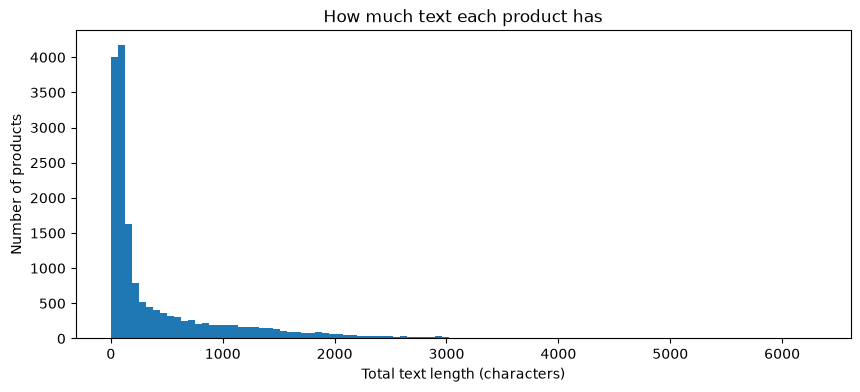

    0 chars | $   5.45 | 
    1 chars | $  11.52 | -
    3 chars | $   9.99 | E12
    3 chars | $  29.83 | Wig
    4 chars | $   8.50 | Envy
    6 chars | $ 205.00 | MADAWI
    6 chars | $  41.49 | #1B BC
    7 chars | $   8.45 | DND 015
    7 chars | $  11.74 | DND 586
    9 chars | $  78.80 | Tape #613


In [11]:
# Apply your chosen price range
curated = priced[(priced["price"] >= 5) & (priced["price"] <= 1400)].copy()

# Combine all text into one string per product
def full_text(row):
    return " ".join([str(row["title"])] + row["features"] + row["description"])

curated["text"] = curated.apply(full_text, axis=1)
curated["text_len"] = curated["text"].str.len()

# Summary of text lengths
print(curated["text_len"].describe())

# Histogram
plt.figure(figsize=(10, 4))
plt.hist(curated["text_len"], bins=100)
plt.xlabel("Total text length (characters)")
plt.ylabel("Number of products")
plt.title("How much text each product has")
plt.show()

# The 10 products with the least text
for i, row in curated.nsmallest(10, "text_len").iterrows():
    print(f"{row['text_len']:>5} chars | ${row['price']:>7.2f} | {row['text'][:90]}")

In [12]:
# Text length at several percentiles
for p in [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90]:
    print(f"{int(p * 100):>3}th percentile: {curated['text_len'].quantile(p):.0f} chars")

# Try a candidate minimum
min_len = 65          # <- placeholder, replace with your choice
kept = curated[curated["text_len"] >= min_len]
print(f"\nMinimum {min_len} chars keeps {len(kept)} of {len(curated)} products "
      f"({len(kept) / len(curated) * 100:.1f}%)")

# See what products just ABOVE your cutoff look like
for i, row in kept.nsmallest(5, "text_len").iterrows():
    print(f"{row['text_len']:>5} chars | ${row['price']:>7.2f} | {row['text'][:90]}")

  1th percentile: 24 chars
  5th percentile: 36 chars
 10th percentile: 44 chars
 25th percentile: 65 chars
 50th percentile: 136 chars
 75th percentile: 588 chars
 90th percentile: 1380 chars

Minimum 65 chars keeps 12770 of 17010 products (75.1%)
   65 chars | $  36.95 | 19pc LA Girl Gel Glide Eyeliner Pencil set of 19 color #GP351-369
   65 chars | $  29.47 | Ogx Conditioner Orchid Oil Fade Defying 13 Ounce (385ml) (2 Pack)
   65 chars | $  21.95 | NEW Walker Extenda-Bond Plus Minis Double Sided Tape Tabs(2-Pack)
   65 chars | $  81.33 | Kenzo World by Kenzo Eau De Parfum Intense Spray 2.5 oz for Women
   65 chars | $  18.95 | Suva Beauty Liquid Chrome Illuminating Drops In Trust Fund 0.5 Oz


In [ ]:
"""Where we are

Here's the whole pipeline so far, as a funnel. The last number is approximate (75% of 17,010):

Raw products              ~112,600   ████████████████████████████████████████
   │  Step 2: drop missing price  (−84.3%)
   ▼
With a price                17,704   ██████
   │  Step 3: keep $5–$1400        (−3.9%)
   ▼
Plausible price             17,010   ██████
   │  Step 4: min 65 chars         (≈ −25%)
   ▼
Enough text               ≈ 12,760   ████

From about 112,600 raw products down to about 12,760 usable ones: roughly 1 in 9 survived. This is the "work backwards" lesson from earlier, now with your own numbers."""

## CURATED DATASET

In [13]:
# APPLYING OUR CURATION FILTER 
curated = curated[curated["text_len"] >= 65].copy()
print(f"Products after text filter: {len(curated)}")

Products after text filter: 12770


Step 5: Characters vs tokens

Concept: an LLM doesn't read characters. The tokenizer first splits text into tokens, which are chunks of text, often a word or part of a word. Model limits and API prices are all counted in tokens, not characters.

In [ ]:
"""Text:     "Moisturizing face cream, 50ml"
             │
             ▼  tokenizer
Tokens:   [Moist] [ur] [izing] [ face] [ cream] [,] [ 50] [ml]
             │
             ▼
Count:    8 tokens  (but 29 characters)"""

(The exact split depends on the tokenizer. This is just to illustrate the idea.)

Because the ratio between characters and tokens varies, "1,380 characters" doesn't tell us exactly how many tokens that is. So we'll measure the real thing.

In [14]:
# pip install tiktoken
import tiktoken
enc = tiktoken.get_encoding("o200k_base")   # the tokenizer used by GPT-4o-family models

In [15]:
curated["tokens"] = curated["text"].apply(lambda t: len(enc.encode(t)))

print(curated["tokens"].describe())

for p in [0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"{int(p * 100):>3}th percentile: {curated['tokens'].quantile(p):.0f} tokens")

ratio = curated["text_len"].sum() / curated["tokens"].sum()
print(f"\nAverage characters per token: {ratio:.2f}")

count    12770.000000
mean       135.089585
std        156.064367
min         10.000000
25%         29.000000
50%         62.500000
75%        190.750000
max       1643.000000
Name: tokens, dtype: float64
 50th percentile: 62 tokens
 75th percentile: 191 tokens
 90th percentile: 355 tokens
 95th percentile: 462 tokens
 99th percentile: 683 tokens

Average characters per token: 4.38


In [16]:
total_tokens = curated["tokens"].sum()

for cap in [200, 355, 462, 683]:
    trimmed = (curated["tokens"] > cap).mean() * 100
    kept_tokens = curated["tokens"].clip(upper=cap).sum()
    print(f"cap {cap:>4} tokens | products trimmed: {trimmed:5.1f}% | "
          f"text kept: {kept_tokens / total_tokens * 100:5.1f}% | "
          f"total tokens: {kept_tokens:,}")

cap  200 tokens | products trimmed:  24.0% | text kept:  70.2% | total tokens: 1,211,540
cap  355 tokens | products trimmed:  10.0% | text kept:  88.9% | total tokens: 1,533,901
cap  462 tokens | products trimmed:   5.0% | text kept:  94.7% | total tokens: 1,633,772
cap  683 tokens | products trimmed:   1.0% | text kept:  99.0% | total tokens: 1,708,043


In [17]:
MAX_TOKENS = 355

def truncate(text):
    tokens = enc.encode(text)
    return enc.decode(tokens[:MAX_TOKENS])

curated["text"] = curated["text"].apply(truncate)
curated["tokens"] = curated["text"].apply(lambda t: len(enc.encode(t)))
print(curated["tokens"].max())      # should be 355 or very close

355


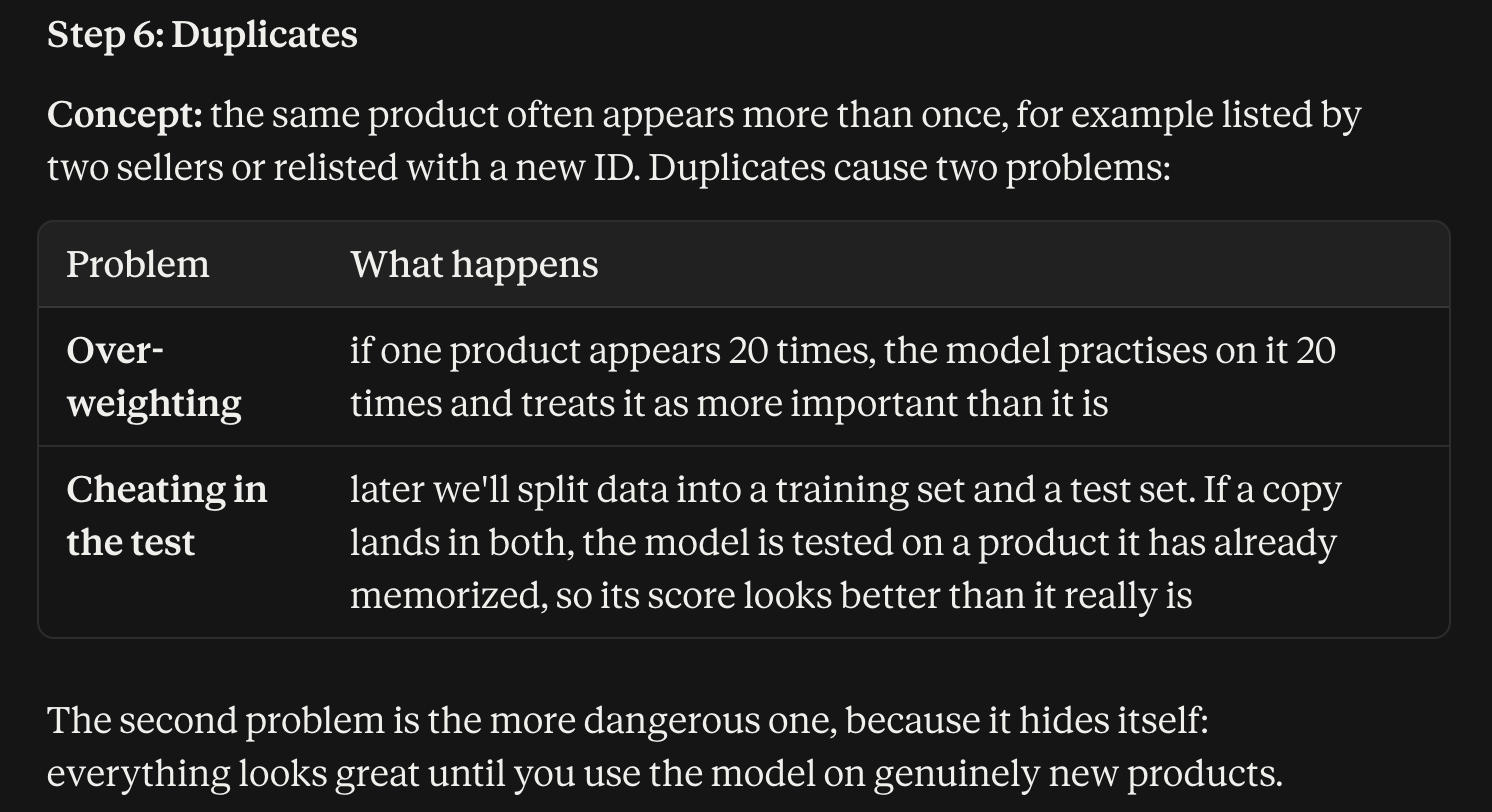

In [18]:
dup_mask = curated.duplicated(subset="text", keep=False)
print(f"Products whose text appears more than once: {dup_mask.sum()}")
print(f"Extra copies (beyond the first): {curated.duplicated(subset='text').sum()}")

# Look at some duplicate groups, and check whether their prices agree
dups = curated[dup_mask].sort_values("text")
for text, group in list(dups.groupby("text"))[:5]:
    print("=" * 80)
    print(text[:90])
    print("Prices:", list(group["price"]))

Products whose text appears more than once: 216
Extra copies (beyond the first): 118
'Topco Sale Lure For Her Pheromone Base Fragrance, 1 oz Spray Bottle' by TOPCO SALE 'Topco
Prices: [14.99, 14.99]
12 Pair Magnetic Eyelash Kit, 10-Pair Reusable Natural Lashes, 2 Pair Fluffy False Eyelash
Prices: [14.99, 15.99]
2 Pack-Prosa Mascara For Enlarging Eyelashes 1 rimel con aceite de mamey oil Enlarging Eye
Prices: [8.69, 7.99]
2021 Popular Glitter Lipstick 18 Color Diamond Shiny Long Lasting Noble Lipstick Easy To C
Prices: [8.99, 8.99, 8.99]
23.5cm Color Wheel, Creative Color Wheel Color Mixing Pocket Guide Chromatic Circle Colors
Prices: [7.49, 7.06]


In [19]:
groups = curated[dup_mask].groupby("text")["price"]
spread = (groups.max() / groups.min())      # 1.0 = same price; 2.0 = one is double the other

print(f"Duplicate groups: {len(spread)}")
print(f"Groups where all prices match: {(spread == 1).sum()}")
print(f"Groups within 20% of each other: {((spread > 1) & (spread <= 1.2)).sum()}")
print(f"Groups where one price is over 1.2x the other: {(spread > 1.2).sum()}")

Duplicate groups: 98
Groups where all prices match: 53
Groups within 20% of each other: 33
Groups where one price is over 1.2x the other: 12


In [20]:
sizes = curated[dup_mask].groupby("text").size()
print(sizes.value_counts().sort_index())

2    83
3    11
4     3
5     1
Name: count, dtype: int64


Drop all 12 far-apart groups entirely.

Here's the reasoning:

You can't know which price is true. If one listing says $10 and another says $40 for identical text, one of them is wrong, maybe a bundle, a typo, or a different seller's markup. Nothing in the data tells you which.
Averaging creates a fiction. Since most groups have just 2 copies, median = mean, and the model would learn $25, a price neither listing had.
It costs almost nothing. 12 groups with mostly 2–3 copies each is roughly 25–30 products out of 12,770, about 0.2%.

That third point is the general principle: when conflicting data is rare, dropping it is cheap and safe. You only need a clever fix when dropping would cost a lot of data.

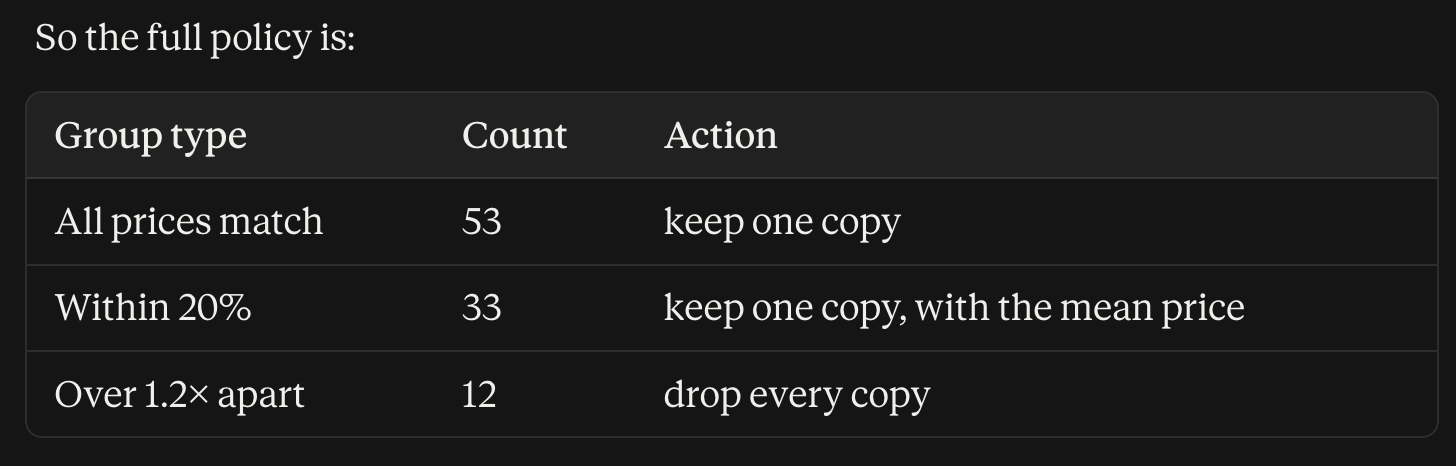

In [21]:
g = curated.groupby("text")["price"]
ratio = g.transform("max") / g.transform("min")

# 1. Drop groups whose prices disagree by more than 20%
curated = curated[ratio <= 1.2].copy()

# 2. Give every remaining copy its group's mean price
curated["price"] = curated.groupby("text")["price"].transform("mean")

# 3. Keep one copy per text
curated = curated.drop_duplicates(subset="text").copy()

print(f"Products after deduplication: {len(curated)}")

Products after deduplication: 12640


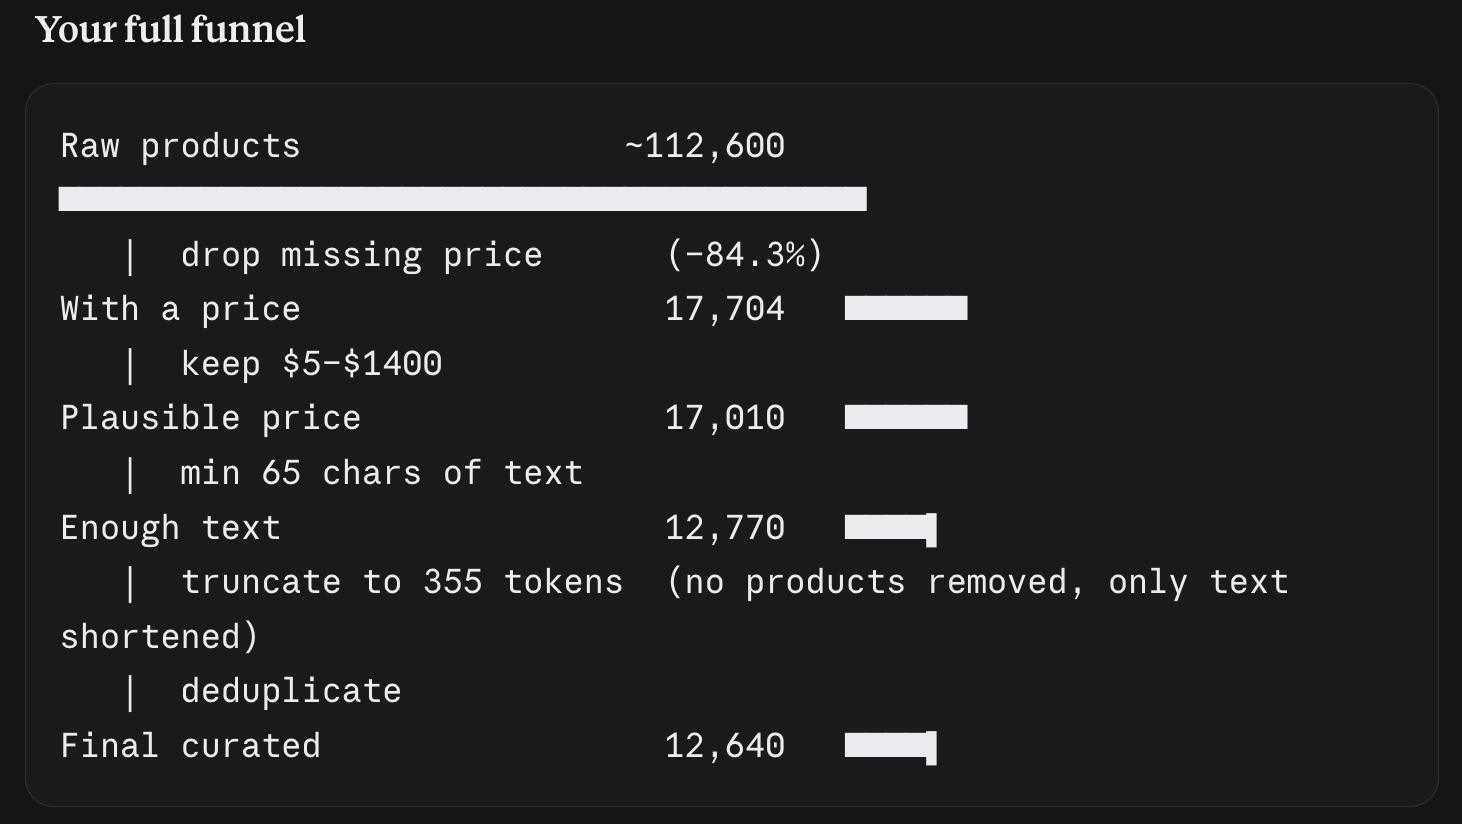

In [22]:
QUESTION = "How much does this cost to the nearest dollar?"

def make_prompt(row):
    return f"{QUESTION}\n\n{row['text']}\n\nPrice is ${round(row['price']):.2f}"

def make_test_prompt(row):
    return f"{QUESTION}\n\n{row['text']}\n\nPrice is $"

curated["prompt"] = curated.apply(make_prompt, axis=1)
curated["test_prompt"] = curated.apply(make_test_prompt, axis=1)

print(curated["prompt"].iloc[0])
print("\n" + "=" * 80 + "\n")
print(curated["test_prompt"].iloc[0])

How much does this cost to the nearest dollar?

Lurrose 100Pcs Full Cover Fake Toenails Artificial Transparent Nail Tips Nail Art for DIY The false toenails are durable with perfect length. You have the option to wear them long or clip them short, easy to trim and file them to in any length and shape you like. ABS is kind of green enviromental material, and makes the nails durable, breathable, light even no pressure on your own nails. Fit well to your natural toenails. Non toxic, no smell, no harm to your health. Wonderful as gift for girlfriend, family and friends. The easiest and most efficient way to do your toenail tips for manicures or nail art designs. It's fashion, creative, a useful accessory brighten up your look, also as a gift. Description The false toenails are durable with perfect length. You have the option to wear them long or clip them short, easy to trim and file them to in any length and shape you like. Plus, ABS is kind of green enviromental material, and makes the n